In [1]:
import sys

# import utils.kitti_loader as kitti_loader

sys.path.append('../')  # Adjust this path based on where your utils directory is located
import utils.kitti_loader as kitti_loader

lidar = kitti_loader.get_LiDAR(count=2)
print(f"Loaded {len(lidar) if isinstance(lidar, (list, tuple)) else 1} LiDAR point clouds from KITTI dataset.")

Loaded 2 LiDAR point clouds from KITTI dataset.


In [2]:
intensity = []
for i in lidar:
    intensity.append(i[:, 3])


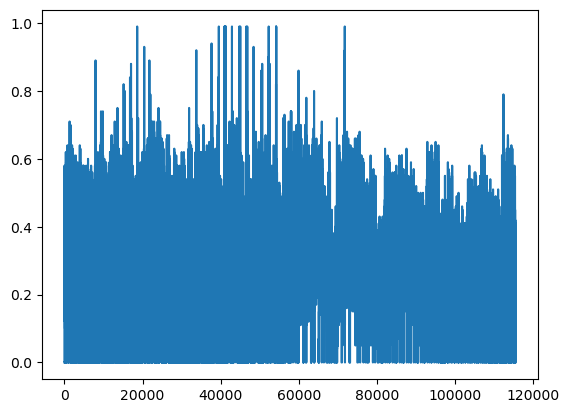

In [3]:
import matplotlib.pyplot as plt
plt.plot(intensity[0])

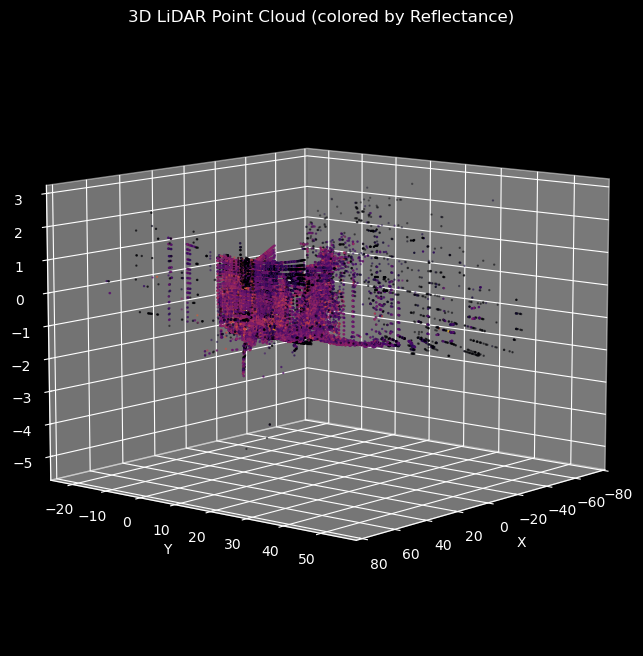

In [4]:
import matplotlib.pyplot as plt 

plt.style.use('dark_background')
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    lidar[0][:, 0], lidar[0][:, 1], lidar[0][:, 2], c=lidar[0][:, 3], s=0.5, cmap='inferno'
)
ax.view_init(elev=10, azim=40)  
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("3D LiDAR Point Cloud (colored by Reflectance)")
plt.show()


In [5]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

points = lidar[0][:, :3]
 
distances = np.linalg.norm(points, axis=1)
 
d_min, d_max = np.percentile(distances, [1, 99])
distances_clipped = np.clip(distances, d_min, d_max)
 
distances_norm = (distances_clipped - distances_clipped.min()) / (distances_clipped.max() - distances_clipped.min())
 
colormap = plt.get_cmap('inferno') 
colors = colormap(distances_norm)[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

o3d.visualization.draw_geometries([pcd],
                                  window_name="KITTI LiDAR Point Cloud (Distance Color)",
                                  width=1280, height=720,
                                  left=50, top=50,
                                  point_show_normal=False)

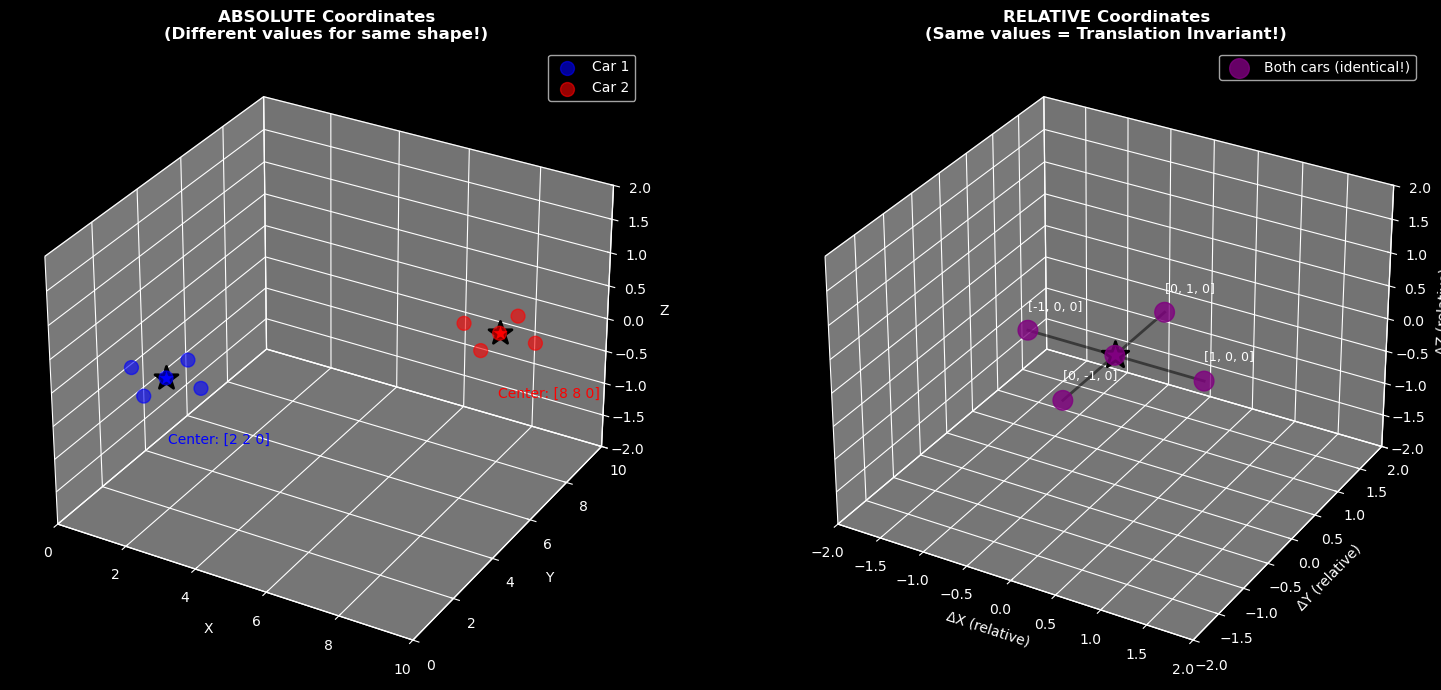

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_relative_coordinates():
    """Show why we use relative coordinates"""
    
    fig = plt.figure(figsize=(16, 7))
    
    # ===== LEFT: Absolute Coordinates =====
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Two identical cars at different positions
    car1_center = np.array([2, 2, 0])
    car1_points = car1_center + np.array([
        [0, 0, 0],    # center
        [1, 0, 0],    # right
        [-1, 0, 0],   # left
        [0, 1, 0],    # front
        [0, -1, 0],   # back
    ])
    
    car2_center = np.array([8, 8, 0])
    car2_points = car2_center + np.array([
        [0, 0, 0],
        [1, 0, 0],
        [-1, 0, 0],
        [0, 1, 0],
        [0, -1, 0],
    ])
    
    # Plot cars
    ax1.scatter(car1_points[:, 0], car1_points[:, 1], car1_points[:, 2], 
                c='blue', s=100, label='Car 1', alpha=0.6)
    ax1.scatter(car2_points[:, 0], car2_points[:, 1], car2_points[:, 2], 
                c='red', s=100, label='Car 2', alpha=0.6)
    
    # Highlight centers
    ax1.scatter(*car1_center, c='blue', s=300, marker='*', 
                edgecolors='black', linewidths=2)
    ax1.scatter(*car2_center, c='red', s=300, marker='*', 
                edgecolors='black', linewidths=2)
    
    # Show absolute coordinates
    ax1.text(2, 2, -1, f'Center: {car1_center}', fontsize=10, color='blue')
    ax1.text(8, 8, -1, f'Center: {car2_center}', fontsize=10, color='red')
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('ABSOLUTE Coordinates\n(Different values for same shape!)', 
                  fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_zlim(-2, 2)
    
    # ===== RIGHT: Relative Coordinates =====
    ax2 = fig.add_subplot(122, projection='3d')
    
    # Relative coordinates (same for both cars!)
    relative_coords = np.array([
        [0, 0, 0],    # center to center
        [1, 0, 0],    # center to right
        [-1, 0, 0],   # center to left
        [0, 1, 0],    # center to front
        [0, -1, 0],   # center to back
    ])
    
    # Plot relative coordinates (overlapping)
    ax2.scatter(relative_coords[:, 0], relative_coords[:, 1], relative_coords[:, 2], 
                c='purple', s=200, label='Both cars (identical!)', alpha=0.8)
    
    # Highlight center
    ax2.scatter(0, 0, 0, c='purple', s=400, marker='*', 
                edgecolors='black', linewidths=2)
    
    # Draw edges
    for i in range(1, len(relative_coords)):
        ax2.plot([0, relative_coords[i, 0]], 
                [0, relative_coords[i, 1]], 
                [0, relative_coords[i, 2]], 
                'k-', linewidth=2, alpha=0.5)
    
    # Annotate
    ax2.text(1, 0, 0.3, '[1, 0, 0]', fontsize=9)
    ax2.text(-1, 0, 0.3, '[-1, 0, 0]', fontsize=9)
    ax2.text(0, 1, 0.3, '[0, 1, 0]', fontsize=9)
    ax2.text(0, -1, 0.3, '[0, -1, 0]', fontsize=9)
    
    ax2.set_xlabel('ΔX (relative)')
    ax2.set_ylabel('ΔY (relative)')
    ax2.set_zlabel('ΔZ (relative)')
    ax2.set_title('RELATIVE Coordinates\n(Same values = Translation Invariant!)', 
                  fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)
    ax2.set_zlim(-2, 2)
    
    plt.tight_layout()
    plt.savefig('relative_vs_absolute.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_relative_coordinates()

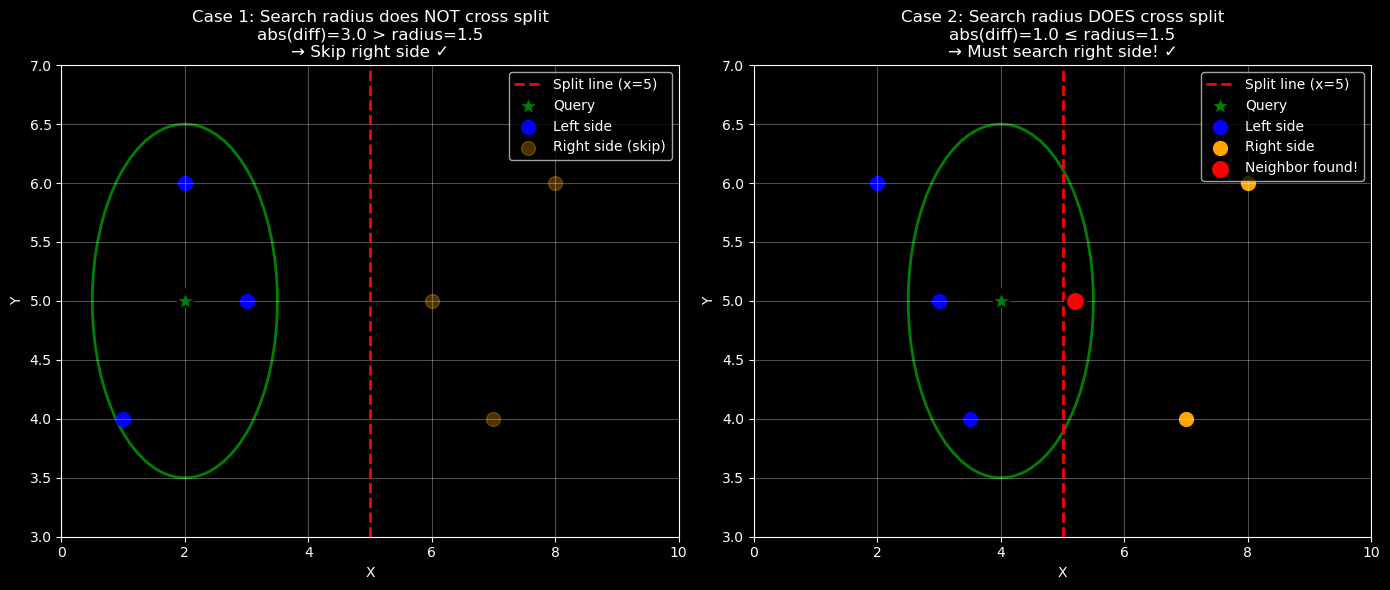

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_kdtree_search_issue():
    """
    Visualize why we need to search both sides of KD-Tree
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Scenario 1: Query point far from splitting plane
    ax1 = axes[0]
    ax1.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Split line (x=5)')
    
    # Query point on left side, far from split
    query1 = np.array([2.0, 5.0])
    ax1.scatter(*query1, s=300, c='green', marker='*', 
                edgecolors='black', linewidths=2, zorder=5, label='Query')
    circle1 = plt.Circle(query1, 1.5, color='green', fill=False, linewidth=2)
    ax1.add_patch(circle1)
    
    # Points
    left_points = np.array([[1, 4], [2, 6], [3, 5]])
    right_points = np.array([[6, 5], [7, 4], [8, 6]])
    
    ax1.scatter(left_points[:, 0], left_points[:, 1], s=100, c='blue', label='Left side')
    ax1.scatter(right_points[:, 0], right_points[:, 1], s=100, c='orange', 
                alpha=0.3, label='Right side (skip)')
    
    ax1.set_xlim(0, 10)
    ax1.set_ylim(3, 7)
    ax1.set_title('Case 1: Search radius does NOT cross split\nabs(diff)=3.0 > radius=1.5\n→ Skip right side ✓')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    
    # Scenario 2: Query point near splitting plane
    ax2 = axes[1]
    ax2.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Split line (x=5)')
    
    # Query point on left side, but CLOSE to split
    query2 = np.array([4.0, 5.0])
    ax2.scatter(*query2, s=300, c='green', marker='*', 
                edgecolors='black', linewidths=2, zorder=5, label='Query')
    circle2 = plt.Circle(query2, 1.5, color='green', fill=False, linewidth=2)
    ax2.add_patch(circle2)
    
    # Points - one on right side is within radius!
    left_points2 = np.array([[3, 5], [2, 6], [3.5, 4]])
    right_points2 = np.array([[5.2, 5], [7, 4], [8, 6]])  # First point is within radius!
    
    ax2.scatter(left_points2[:, 0], left_points2[:, 1], s=100, c='blue', label='Left side')
    ax2.scatter(right_points2[:, 0], right_points2[:, 1], s=100, c='orange', label='Right side')
    ax2.scatter(right_points2[0, 0], right_points2[0, 1], s=200, c='red', 
                edgecolors='black', linewidths=2, zorder=4, label='Neighbor found!')
    
    ax2.set_xlim(0, 10)
    ax2.set_ylim(3, 7)
    ax2.set_title('Case 2: Search radius DOES cross split\nabs(diff)=1.0 ≤ radius=1.5\n→ Must search right side! ✓')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    
    plt.tight_layout()
    plt.savefig('kdtree_both_sides.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_kdtree_search_issue()

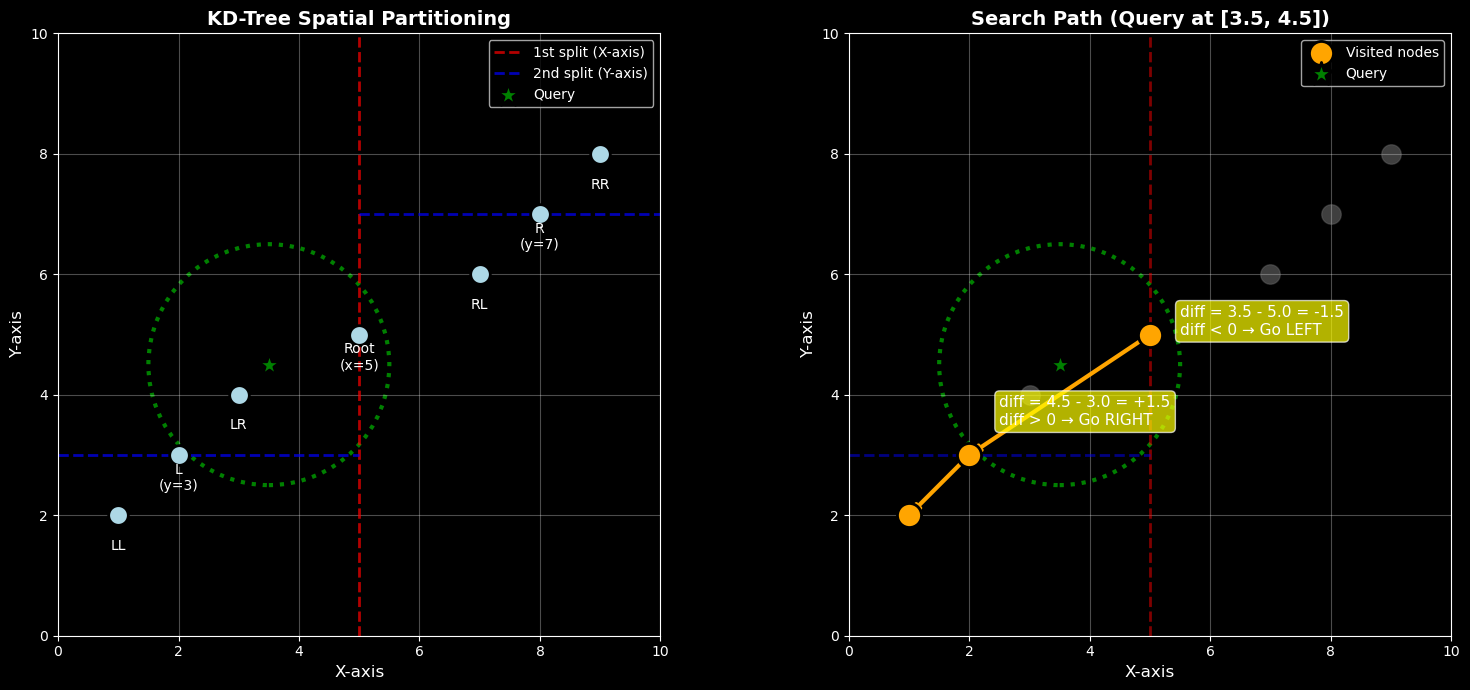

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_kdtree_split():
    """Show how KD-Tree partitions space"""
    
    # Create sample points
    points = np.array([
        [5, 5],  # Root node (splits on X)
        [2, 3],  # Left child (splits on Y)
        [8, 7],  # Right child (splits on Y)
        [1, 2],  # Left-left
        [3, 4],  # Left-right
        [7, 6],  # Right-left
        [9, 8],  # Right-right
    ])
    
    query = np.array([3.5, 4.5])
    radius = 2.0
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # ===== LEFT PLOT: Tree Structure =====
    ax1 = axes[0]
    
    # Draw points
    ax1.scatter(points[:, 0], points[:, 1], s=200, c='lightblue', 
                edgecolors='black', linewidths=2, zorder=3)
    
    # Label points
    labels = ['Root\n(x=5)', 'L\n(y=3)', 'R\n(y=7)', 
              'LL', 'LR', 'RL', 'RR']
    for i, (point, label) in enumerate(zip(points, labels)):
        ax1.annotate(label, point, fontsize=10, ha='center', 
                    xytext=(0, -25), textcoords='offset points')
    
    # Draw split lines
    # Root splits on X at x=5
    ax1.axvline(5, color='red', linewidth=2, linestyle='--', 
                label='1st split (X-axis)', alpha=0.7)
    
    # Left child splits on Y at y=3
    ax1.plot([0, 5], [3, 3], color='blue', linewidth=2, 
             linestyle='--', label='2nd split (Y-axis)', alpha=0.7)
    
    # Right child splits on Y at y=7
    ax1.plot([5, 10], [7, 7], color='blue', linewidth=2, 
             linestyle='--', alpha=0.7)
    
    # Draw query point and search radius
    ax1.scatter(query[0], query[1], s=300, c='green', marker='*', 
                edgecolors='black', linewidths=2, zorder=4, label='Query')
    circle = plt.Circle(query, radius, color='green', fill=False, 
                       linestyle=':', linewidth=3)
    ax1.add_patch(circle)
    
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_xlabel('X-axis', fontsize=12)
    ax1.set_ylabel('Y-axis', fontsize=12)
    ax1.set_title('KD-Tree Spatial Partitioning', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # ===== RIGHT PLOT: Search Path =====
    ax2 = axes[1]
    
    # Draw all points faded
    ax2.scatter(points[:, 0], points[:, 1], s=200, c='lightgray', 
                edgecolors='gray', linewidths=1, zorder=2, alpha=0.3)
    
    # Highlight search path
    search_path = [0, 1, 3]  # Root -> Left -> Left-Left
    path_points = points[search_path]
    
    # Draw arrows showing search path
    for i in range(len(path_points) - 1):
        ax2.annotate('', xy=path_points[i+1], xytext=path_points[i],
                    arrowprops=dict(arrowstyle='->', lw=3, color='orange'))
    
    # Highlight visited nodes
    ax2.scatter(path_points[:, 0], path_points[:, 1], s=300, 
                c='orange', edgecolors='black', linewidths=2, 
                zorder=3, label='Visited nodes')
    
    # Show the decision at each split
    ax2.text(5.5, 5, 'diff = 3.5 - 5.0 = -1.5\ndiff < 0 → Go LEFT', 
             fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    ax2.text(2.5, 3.5, 'diff = 4.5 - 3.0 = +1.5\ndiff > 0 → Go RIGHT', 
             fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Draw split lines
    ax2.axvline(5, color='red', linewidth=2, linestyle='--', alpha=0.5)
    ax2.plot([0, 5], [3, 3], color='blue', linewidth=2, linestyle='--', alpha=0.5)
    
    # Draw query
    ax2.scatter(query[0], query[1], s=300, c='green', marker='*', 
                edgecolors='black', linewidths=2, zorder=4, label='Query')
    circle = plt.Circle(query, radius, color='green', fill=False, 
                       linestyle=':', linewidth=3)
    ax2.add_patch(circle)
    
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.set_xlabel('X-axis', fontsize=12)
    ax2.set_ylabel('Y-axis', fontsize=12)
    ax2.set_title('Search Path (Query at [3.5, 4.5])', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig('kdtree_search_explained.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_kdtree_split()

In [9]:
def explain_kdtree_search():
    """
    Detailed walkthrough of KD-Tree search logic
    """
    
    # Example tree structure
    print("=" * 60)
    print("KD-TREE SEARCH EXPLANATION")
    print("=" * 60)
    
    query_point = np.array([3.5, 4.5])
    radius = 2.0
    
    print(f"\nSearching for neighbors of {query_point} within radius {radius}\n")
    
    # Node 1: Root (splits on X-axis at x=5.0)
    print("Step 1: At ROOT node")
    print("-" * 40)
    node_point = np.array([5.0, 5.0])
    axis = 0  # X-axis
    
    diff = query_point[axis] - node_point[axis]
    print(f"  Node position: {node_point}")
    print(f"  Split axis: {axis} (X-axis)")
    print(f"  diff = query[{axis}] - node[{axis}]")
    print(f"  diff = {query_point[axis]} - {node_point[axis]} = {diff}")
    print(f"\n  Decision: diff < 0? {diff < 0}")
    
    if diff < 0:
        print(f"  → Query is LEFT of split (x < 5.0)")
        print(f"  → Search LEFT subtree first")
        next_node = "LEFT"
    else:
        print(f"  → Query is RIGHT of split (x >= 5.0)")
        print(f"  → Search RIGHT subtree first")
        next_node = "RIGHT"
    
    # Check if need to search other side
    print(f"\n  Should we also check the other side?")
    print(f"  |diff| = {abs(diff)} vs radius = {radius}")
    
    if abs(diff) <= radius:
        print(f"  → YES! Search radius crosses the split plane")
        print(f"  → Must also check {('RIGHT' if next_node == 'LEFT' else 'LEFT')} subtree")
    else:
        print(f"  → NO! Split plane is too far away")
        print(f"  → Can safely ignore {('RIGHT' if next_node == 'LEFT' else 'LEFT')} subtree")
    
    print("\n" + "=" * 60)
    
    # Node 2: Left child (splits on Y-axis at y=3.0)
    print("\nStep 2: At LEFT child node")
    print("-" * 40)
    node_point = np.array([2.0, 3.0])
    axis = 1  # Y-axis
    
    diff = query_point[axis] - node_point[axis]
    print(f"  Node position: {node_point}")
    print(f"  Split axis: {axis} (Y-axis)")
    print(f"  diff = query[{axis}] - node[{axis}]")
    print(f"  diff = {query_point[axis]} - {node_point[axis]} = {diff}")
    print(f"\n  Decision: diff < 0? {diff < 0}")
    
    if diff < 0:
        print(f"  → Query is BELOW split (y < 3.0)")
        print(f"  → Search LEFT subtree (lower Y values)")
    else:
        print(f"  → Query is ABOVE split (y >= 3.0)")
        print(f"  → Search RIGHT subtree (higher Y values)")
    
    print("\n" + "=" * 60)

explain_kdtree_search()

KD-TREE SEARCH EXPLANATION

Searching for neighbors of [3.5 4.5] within radius 2.0

Step 1: At ROOT node
----------------------------------------
  Node position: [5. 5.]
  Split axis: 0 (X-axis)
  diff = query[0] - node[0]
  diff = 3.5 - 5.0 = -1.5

  Decision: diff < 0? True
  → Query is LEFT of split (x < 5.0)
  → Search LEFT subtree first

  Should we also check the other side?
  |diff| = 1.5 vs radius = 2.0
  → YES! Search radius crosses the split plane
  → Must also check RIGHT subtree


Step 2: At LEFT child node
----------------------------------------
  Node position: [2. 3.]
  Split axis: 1 (Y-axis)
  diff = query[1] - node[1]
  diff = 4.5 - 3.0 = 1.5

  Decision: diff < 0? False
  → Query is ABOVE split (y >= 3.0)
  → Search RIGHT subtree (higher Y values)



In [10]:
class KDTreeWithCounter:
    """KD-Tree that counts how many nodes it visits"""
    
    def __init__(self, points):
        self.points = points
        self.root = self._build_tree(points, np.arange(len(points)), 0)
    
    def _build_tree(self, points, indices, depth):
        if len(points) == 0:
            return None
        
        axis = depth % 3
        sorted_idx = np.argsort(points[:, axis])
        median_idx = len(points) // 2
        
        node = KDNode(
            point=points[sorted_idx[median_idx]],
            index=indices[sorted_idx[median_idx]],
            axis=axis
        )
        
        node.left = self._build_tree(
            points[sorted_idx[:median_idx]],
            indices[sorted_idx[:median_idx]],
            depth + 1
        )
        node.right = self._build_tree(
            points[sorted_idx[median_idx + 1:]],
            indices[sorted_idx[median_idx + 1:]],
            depth + 1
        )
        
        return node
    
    def query_with_count(self, query_point, radius):
        """Query and count how many nodes visited"""
        result = []
        visited_count = [0]  # Use list to make it mutable in nested function
        
        def search(node):
            if node is None:
                return
            
            visited_count[0] += 1  # Count this visit
            
            # Check if in radius
            distance = np.linalg.norm(node.point - query_point)
            if distance <= radius:
                result.append(node.index)
            
            # Decide which way to go
            axis = node.axis
            diff = query_point[axis] - node.point[axis]
            
            if diff < 0:
                search(node.left)
                if abs(diff) <= radius:
                    search(node.right)
            else:
                search(node.right)
                if abs(diff) <= radius:
                    search(node.left)
        
        search(self.root)
        return result, visited_count[0]


# Test different query positions
points = np.random.rand(127, 3) * 10  # 127 points (complete tree)
tree = KDTreeWithCounter(points)

print("Comparing different query positions:\n")

# Case 1: Query at root position
root_point = tree.root.point
neighbors1, count1 = tree.query_with_count(root_point, radius=1.0)
print(f"Query AT ROOT {root_point}:")
print(f"  Visited {count1} out of 127 nodes ({count1/127*100:.1f}%)")
print(f"  Found {len(neighbors1)} neighbors\n")

# Case 2: Query at edge (far from root)
edge_point = np.array([0.5, 0.5, 0.5])
neighbors2, count2 = tree.query_with_count(edge_point, radius=1.0)
print(f"Query at EDGE {edge_point}:")
print(f"  Visited {count2} out of 127 nodes ({count2/127*100:.1f}%)")
print(f"  Found {len(neighbors2)} neighbors\n")

print(f"Efficiency difference: {count1/count2:.1f}x more nodes visited at root!")

NameError: name 'KDNode' is not defined

In [ ]:
import sys
import os
import numpy as np
sys.path.append("../")

In [ ]:
import utils.kitti_loader as kitti_loader


In [ ]:
lidar = kitti_loader.get_LiDAR()

In [ ]:
lidar_sample = lidar[0]

In [ ]:
lidar_sample.shape


(115384, 4)

In [ ]:
a = kitti_loader.lidar_fps_real_time(lidar_sample)
b = kitti_loader.lidar_fps_real_time(lidar_sample)

In [ ]:
a_ = a[:, :3]
b_ = b[:, :3]

In [ ]:
a_ == b_

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]])

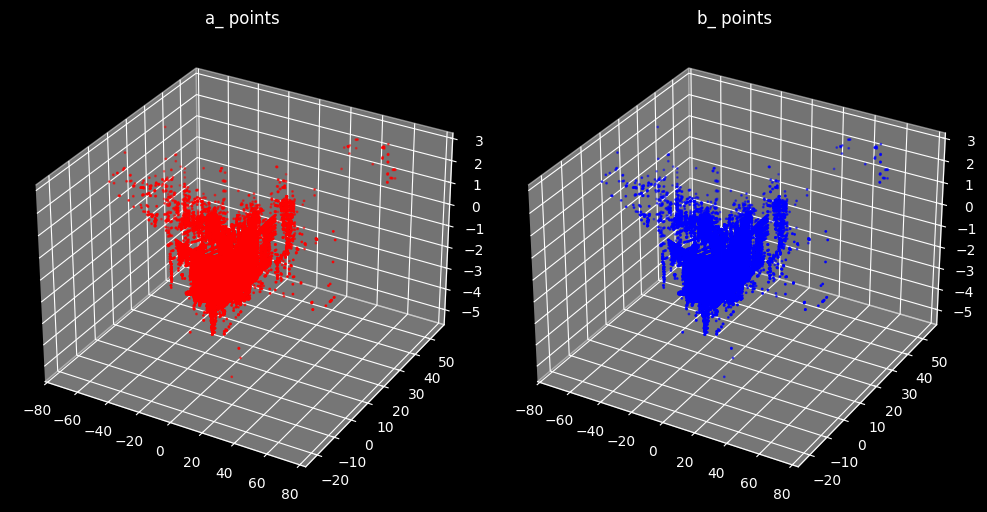

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fig = plt.figure(figsize=(10, 5))

# Left subplot
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(a_[:, 0], a_[:, 1], a_[:, 2], c='r', s=1)
ax1.set_title('a_ points')

# Right subplot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(b_[:, 0], b_[:, 1], b_[:, 2], c='b', s=1)
ax2.set_title('b_ points')

plt.tight_layout()
plt.show()


In [ ]:
import open3d as o3d
import numpy as np

# lidar1_path = r"F:\Work\DeepLearning\Research\dataset\data_object_velodyne\training\velodyne\000000.bin"
lidar2_path = r"F:\Work\DeepLearning\Research\dataset\processed_lidar\training\velodyne\000003.npy"

# # Load LiDAR 1 (.bin)
# pts1 = np.fromfile(lidar1_path, dtype=np.float32).reshape(-1, 4)[:, :3]
# pcd1 = o3d.geometry.PointCloud()
# pcd1.points = o3d.utility.Vector3dVector(pts1)
# pcd1.paint_uniform_color([1, 0, 0])  # red

# Load LiDAR 2 (.npy)
pts2 = np.load(lidar2_path)[:, :3]
pcd2 = o3d.geometry.PointCloud()
pcd2.points = o3d.utility.Vector3dVector(pts2)
pcd2.paint_uniform_color([0, 1, 0])  # green

# Shift second point cloud to the right for side-by-side view
shift = np.array([50, 0, 0])
pcd2.translate(shift)

o3d.visualization.draw_geometries([ pcd2])


In [ ]:
import sys
import os
sys.path.append('../')  # Adjust this path based on where your utils directory is located

import numpy as np
import matplotlib.pyplot as plt
import utils.kitti_loader as kitti_loader

In [ ]:
lidar_points = kitti_loader.get_LiDAR(count=1)
calib_data = kitti_loader.get_calib(count=1)
images = kitti_loader.get_images(count=1)
lidar_processed = np.fromfile(r"F:\Work\DeepLearning\Research\dataset\processed_lidar\training\velodyne\000000.npy", dtype=np.float32).reshape(-1, 4)

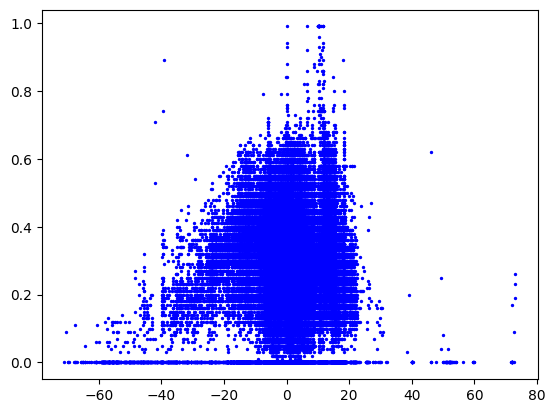

In [ ]:
plt.scatter(lidar_points[0][:, 0], lidar_points[0][:, 3], c='b', s=2)

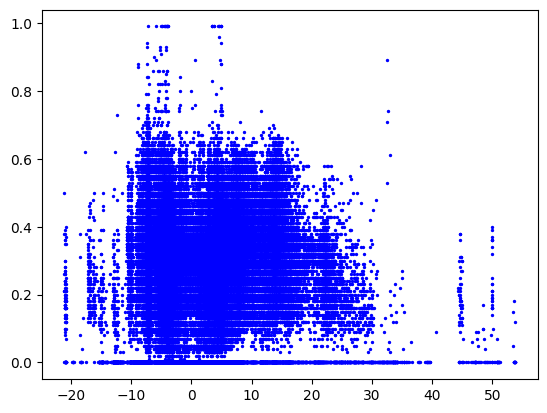

In [ ]:
plt.scatter(lidar_points[0][:, 1], lidar_points[0][:, 3], c='b', s=2)

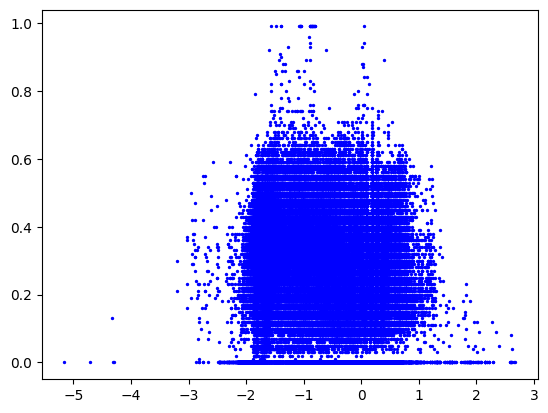

In [ ]:
plt.scatter(lidar_points[0][:, 2], lidar_points[0][:, 3], c='b', s=2)

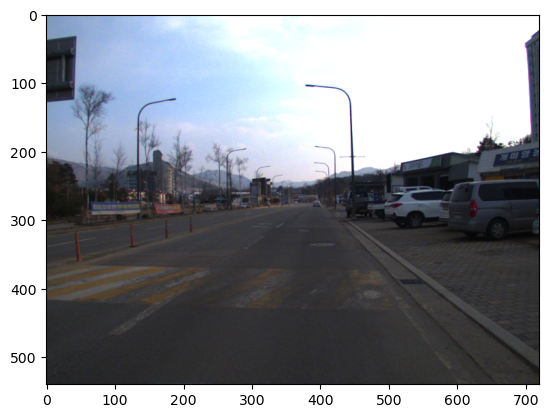

In [12]:
import matplotlib.pyplot as plt
img = plt.imread(r"F:\Work\DeepLearning\Research\visualization\000000(1).png")
plt.imshow(img)

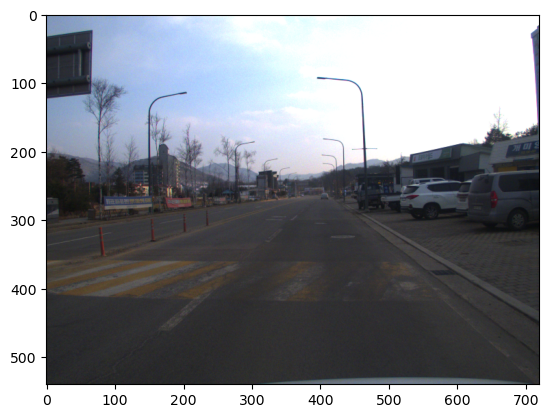

In [11]:
import matplotlib.pyplot as plt
img = plt.imread(r"F:\Work\DeepLearning\Research\visualization\000000.png")
plt.imshow(img)

In [1]:
import open3d as o3d
import numpy as np
import os
import glob
import time

is_paused = False

def key_callback(vis):
    global is_paused
    is_paused = not is_paused
    print("PAUSED" if is_paused else "PLAYING")

def load_kitti_bin(bin_path):
    # KITTI .bin format: [x, y, z, intensity]
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    return points[:, :3], points[:, 3]

def get_intensity_colors(intensity):
    intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min() + 1e-8)

    colors = np.zeros((intensity.shape[0], 3))
    colors[:, 0] = np.clip(1.5 - np.abs(intensity * 4 - 3), 0, 1)
    colors[:, 1] = np.clip(1.5 - np.abs(intensity * 4 - 2), 0, 1)
    colors[:, 2] = np.clip(1.5 - np.abs(intensity * 4 - 1), 0, 1)
    return colors

def visualize_bin_sequence(folder_path):
    global is_paused

    bin_files = sorted(glob.glob(os.path.join(folder_path, "*.bin")))
    if len(bin_files) == 0:
        raise RuntimeError("No .bin files found")

    vis = o3d.visualization.VisualizerWithKeyCallback()
    vis.create_window("BIN Player (SPACE = pause)", 1280, 720)
    vis.register_key_callback(32, key_callback)

    xyz, intensity = load_kitti_bin(bin_files[0])
    colors = get_intensity_colors(intensity)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    vis.add_geometry(pcd)

    opt = vis.get_render_option()
    opt.background_color = np.zeros(3)
    opt.point_size = 2.0

    frame = 0
    total = len(bin_files)

    while True:
        if not is_paused:
            xyz, intensity = load_kitti_bin(bin_files[frame])
            pcd.points = o3d.utility.Vector3dVector(xyz)
            pcd.colors = o3d.utility.Vector3dVector(
                get_intensity_colors(intensity)
            )
            vis.update_geometry(pcd)
            frame = (frame + 1) % total

        if not vis.poll_events():
            break
        vis.update_renderer()
        # time.sleep(0.05)

    vis.destroy_window()

if __name__ == "__main__":
    visualize_bin_sequence(
        r"F:\Work\DeepLearning\Research\V2X-Radar-V\V2X-Radar-V\training\velodyne"
    )


In [19]:
import open3d as o3d
import numpy as np
import os

def visualize_pcd_with_intensity():
    bin_path = r"F:\Work\DeepLearning\Research\V2X-Radar-V\V2X-Radar-V\training\velodyne\000000.bin"

    if not os.path.exists(bin_path):
        raise FileNotFoundError(f"File not found: {bin_path}")

    # KITTI .bin format: [x, y, z, intensity] as float32
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

    xyz = points[:, :3]
    intensity = points[:, 3]

    print(f"Number of points: {xyz.shape[0]}")

    # Normalize intensity to [0, 1]
    intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min() + 1e-8)

    # Create RGB colors from intensity
    colors = np.zeros((xyz.shape[0], 3))
    colors[:, 0] = np.clip(1.5 - np.abs(intensity * 4 - 3), 0, 1)
    colors[:, 1] = np.clip(1.5 - np.abs(intensity * 4 - 2), 0, 1)
    colors[:, 2] = np.clip(1.5 - np.abs(intensity * 4 - 1), 0, 1)

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Visualizer
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name="Point Cloud with Intensity")
    vis.add_geometry(pcd)

    opt = vis.get_render_option()
    opt.background_color = np.asarray([0, 0, 0])
    opt.point_size = 2.0

    ctr = vis.get_view_control()
    ctr.set_zoom(0.8)

    vis.run()
    vis.destroy_window()


if __name__ == "__main__":
    visualize_pcd_with_intensity()


Number of points: 144000


In [16]:
import numpy as np
import os
 
folder_path = r'F:\Work\DeepLearning\Research\V2X-Radar-V\training\velodyne'
 
all_file_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path)]
 
for i in all_file_paths:
    try:
        lidar = np.fromfile(i, dtype=np.float32)
        lidar = lidar.reshape(-1, 4)
    except Exception as e:
        try:
            lidar = lidar.reshape(-1, 3)
            print(".....")
        except Exception as e:
            print(f"Error loading {i}: {e}")

.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....
.....


In [4]:
lidar.reshape(-1, 4)

array([[-6.38324095e+002,  3.95824437e+013, -2.42825184e+008,
         1.37439051e+011],
       [ 2.24711749e+307,  1.05892563e-314, -2.42734560e+008,
         5.24288371e+005],
       [-2.22708760e+007,  5.12000365e+002, -8.47533567e+002,
         6.01295666e+010],
       ...,
       [-1.50091194e+000,  3.43597458e+010, -1.45946907e+000,
         1.03079231e+011],
       [-1.37300514e+000,  6.44245398e+009, -1.94948126e+008,
         8.19200197e+003],
       [-9.88115426e-001,  2.57698077e+010, -1.26123452e+000,
         3.00647832e+010]])

In [17]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

points = lidar[:, :3]
 
distances = np.linalg.norm(points, axis=1)
 
d_min, d_max = np.percentile(distances, [1, 99])
distances_clipped = np.clip(distances, d_min, d_max)
 
distances_norm = (distances_clipped - distances_clipped.min()) / (distances_clipped.max() - distances_clipped.min())
 
colormap = plt.get_cmap('inferno') 
colors = colormap(distances_norm)[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

o3d.visualization.draw_geometries([pcd],
                                  window_name="KITTI LiDAR Point Cloud (Distance Color)",
                                  width=1280, height=720,
                                  left=50, top=50,
                                  point_show_normal=False)

c:\Users\praga\.conda\envs\torch\lib\site-packages\numpy\linalg\_linalg.py:2772: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
c:\Users\praga\.conda\envs\torch\lib\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [16]:
lidar = lidar.reshape(-1, 4)
lidar.shape

(72000, 4)

In [17]:
import numpy as np
data = np.fromfile(r"F:\Work\DeepLearning\Research\V2X-Radar-V\V2X-Radar-V\training\radar\000000.bin", dtype=np.float32).reshape(-1, 5)


In [15]:
data.shape

(9027, 5)

In [1]:
import open3d as o3d
import numpy as np

points = np.fromfile(
    r"F:\Work\DeepLearning\Research\V2X-Radar-V\training\velodyne\000003.bin",
    dtype=np.float32
).reshape(-1, 4)

# 1. Remove NaN and Inf points (CRITICAL)
mask = np.isfinite(points[:, 0]) & np.isfinite(points[:, 1]) & np.isfinite(points[:, 2])
points = points[mask]

print("After cleaning:", points.shape)

# 2. Create point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points[:, :3])

# 3. Visualize point cloud (sanity check)
o3d.visualization.draw_geometries([pcd])

# 4. Choose proper voxel size (LiDAR scale)
voxel_size = 0.2  # meters (DO NOT use bbox/100 here)

# 5. Voxelize
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(
    pcd,
    voxel_size=voxel_size
)

# 6. Visualize voxels
o3d.visualization.draw_geometries([voxel_grid])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
After cleaning: (127641, 4)


In [10]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points[:, :3])
# o3d.visualization.draw_geometries([pcd])

In [18]:
import open3d as o3d
import numpy as np

# assume pcd already exists
scene_size = np.max(pcd.get_max_bound() - pcd.get_min_bound())
v_size = max(scene_size * 0.05, 0.1)

voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(
    pcd, voxel_size=v_size
)

print("Number of voxels:", len(voxel_grid.get_voxels()))

# IMPORTANT: color voxels
# voxel_grid.paint_uniform_color([0.8, 0.8, 0.8])

vis = o3d.visualization.Visualizer()
vis.create_window()
vis.add_geometry(voxel_grid)

opt = vis.get_render_option()
# opt.background_color = np.asarray([0, 0, 0])

vis.reset_view_point(True)   # CRITICAL

vis.run()
vis.destroy_window()


Number of voxels: 84
